# Jump-Diffusion Models (Merton 1976)

Extend GBM with compound-Poisson jumps, simulate fat-tailed return distributions, and price European calls using Merton's analytic series formula.

**Theory references:** [Jump Diffusion](../theory/02_options/jump_diffusion.md) | [Black Scholes](../theory/02_options/black_scholes.md) 

In [1]:
from __future__ import annotations

from math import factorial
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis, norm

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "normal",
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})
COLORS = ["#534AB7", "#0F6E56", "#D85A30", "#185FA5", "#993556", "#3B6D11", "#BA7517"]


def save_fig(fig, topic: str, name: str) -> None:
    folder = os.path.join('..', 'plots', topic)
    os.makedirs(folder, exist_ok=True)
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(folder, f'{name}.{ext}'))


## Section 1 — Merton Model Simulation

### The jump-diffusion SDE

The Merton (1976) model augments geometric Brownian motion with discontinuous jumps
drawn from a **compound Poisson process**:

$$
\frac{dS_t}{S_{t^-}} = (\mu - \lambda\bar{k})\,dt + \sigma\,dW_t + (J - 1)\,dN_t
$$

| Symbol | Meaning |
|--------|---------|
| $\mu$ | drift of the continuous part |
| $\sigma$ | diffusion volatility |
| $W_t$ | standard Brownian motion |
| $N_t$ | Poisson counting process with intensity $\lambda$ (jump arrival rate) |
| $J$ | jump multiplier ($J > 0$); $\ln J \sim \mathcal{N}(\mu_J,\, \sigma_J^2)$ |
| $\bar{k}$ | $\mathbb{E}[J - 1] = e^{\mu_J + \sigma_J^2/2} - 1$ (mean relative jump size) |

The drift correction $-\lambda\bar{k}$ ensures $\mathbb{E}[dS/S] = \mu\,dt$ under the
physical measure, compensating for the expected jump contribution.

### Compound Poisson process

In each discrete time step $[t,\, t + \Delta t)$:

1. Draw the number of jumps: $n \sim \mathrm{Poisson}(\lambda\,\Delta t)$.
2. If $n > 0$, draw $n$ independent log-jump sizes $\ln J_i \sim \mathcal{N}(\mu_J,\, \sigma_J^2)$.
3. The total jump contribution to the log-price is $\sum_{i=1}^{n} \ln J_i$.

The discretised log-price update becomes:

$$
\ln S_{t+\Delta t} = \ln S_t
  + \bigl(\mu - \lambda\bar{k} - \tfrac{1}{2}\sigma^2\bigr)\Delta t
  + \sigma\sqrt{\Delta t}\;Z
  + \sum_{i=1}^{n} \ln J_i,
\qquad Z \sim \mathcal{N}(0,1),\; n \sim \mathrm{Poisson}(\lambda\,\Delta t).
$$

In [2]:
def simulate_merton(
    S0: float,
    mu: float,
    sigma: float,
    lam: float,
    mu_J: float,
    sigma_J: float,
    T: float,
    n_steps: int,
    n_paths: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Simulate Merton jump-diffusion paths.

    Returns (time_grid, paths) where paths has shape (n_paths, n_steps+1).
    """
    dt = T / n_steps
    kbar = np.exp(mu_J + 0.5 * sigma_J**2) - 1.0
    t = np.linspace(0, T, n_steps + 1)
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = S0

    for i in range(n_steps):
        z = rng.normal(size=n_paths)
        n_jumps = rng.poisson(lam * dt, size=n_paths)
        jump_sizes = np.array([
            np.sum(rng.normal(mu_J, sigma_J, size=n)) if n > 0 else 0.0
            for n in n_jumps
        ])
        drift = (mu - lam * kbar - 0.5 * sigma**2) * dt
        diffusion = sigma * np.sqrt(dt) * z
        paths[:, i + 1] = paths[:, i] * np.exp(drift + diffusion + jump_sizes)

    return t, paths

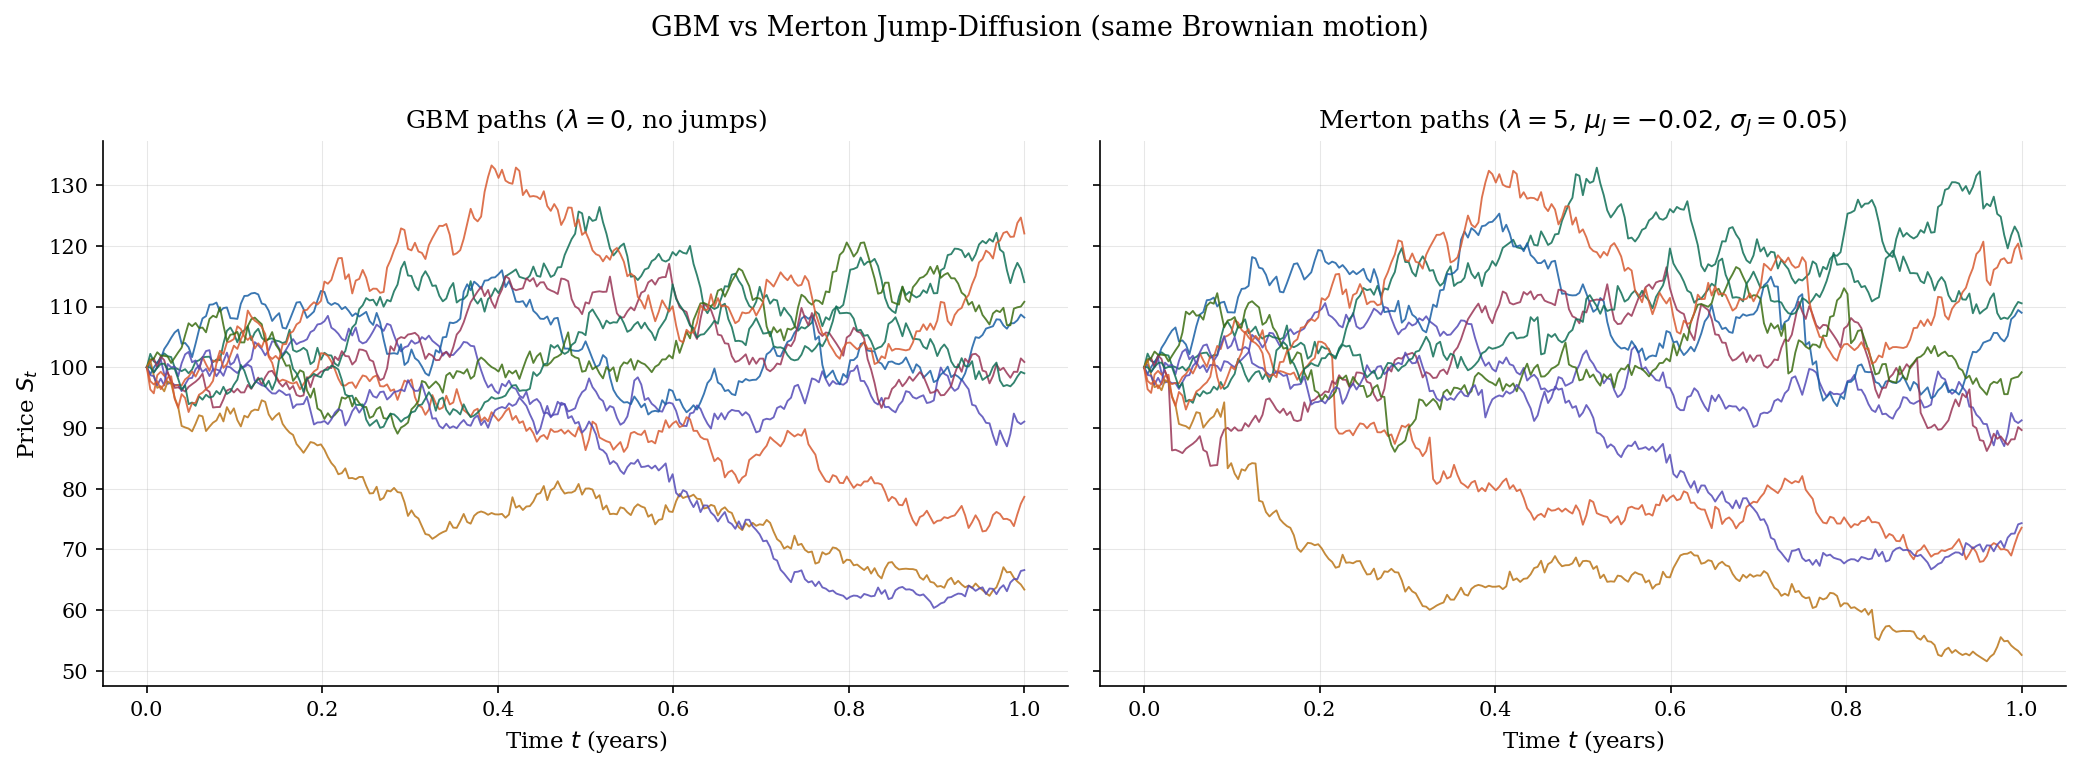

In [28]:
S0, mu, sigma = 100.0, 0.08, 0.2
T, n_steps, n_paths = 1.0, 252, 10
lam, mu_J, sigma_J = 5.0, -0.02, 0.05
dt = T / n_steps
kbar = np.exp(mu_J + 0.5 * sigma_J**2) - 1.0
t = np.linspace(0, T, n_steps + 1)

rng = np.random.default_rng(42)
z = rng.normal(size=(n_paths, n_steps))  # shared BM increments

gbm = np.zeros((n_paths, n_steps + 1))
gbm[:, 0] = S0
for i in range(n_steps):
    gbm[:, i + 1] = gbm[:, i] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z[:, i]
    )

merton = np.zeros((n_paths, n_steps + 1))
merton[:, 0] = S0
for i in range(n_steps):
    nj = rng.poisson(lam * dt, size=n_paths)
    js = np.array([
        np.sum(rng.normal(mu_J, sigma_J, size=n)) if n > 0 else 0.0
        for n in nj
    ])
    merton[:, i + 1] = merton[:, i] * np.exp(
        (mu - lam * kbar - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * z[:, i] + js
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i in range(n_paths):
    ax1.plot(t, gbm[i], lw=0.9, alpha=0.85, color=COLORS[i % len(COLORS)])
ax1.set_title(r'GBM paths ($\lambda = 0$, no jumps)')
ax1.set_xlabel(r'Time $t$ (years)')
ax1.set_ylabel(r'Price $S_t$')

for i in range(n_paths):
    ax2.plot(t, merton[i], lw=0.9, alpha=0.85, color=COLORS[i % len(COLORS)])
ax2.set_title(r'Merton paths ($\lambda=5$, $\mu_J=-0.02$, $\sigma_J=0.05$)')
ax2.set_xlabel(r'Time $t$ (years)')

fig.suptitle('GBM vs Merton Jump-Diffusion (same Brownian motion)', y=1.02, fontsize=13)
fig.tight_layout()
save_fig(fig, '02_options', 'merton_vs_gbm_paths')
plt.show()

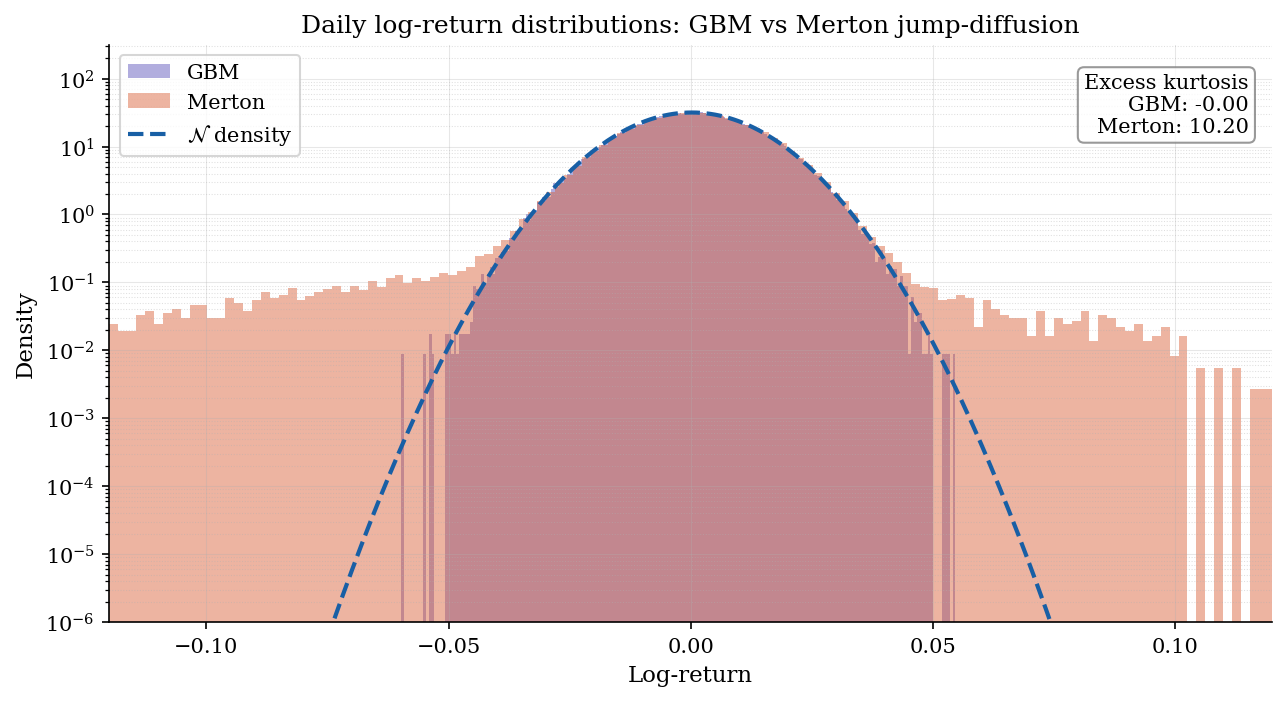

In [27]:
rng_ft = np.random.default_rng(99)
n_sims = 200_000
dt_day = 1.0 / 252

z_shared = rng_ft.normal(size=n_sims)

gbm_lr = (mu - 0.5 * sigma**2) * dt_day + sigma * np.sqrt(dt_day) * z_shared

n_jumps_day = rng_ft.poisson(lam * dt_day, size=n_sims)
jump_contrib = np.array([
    np.sum(rng_ft.normal(mu_J, sigma_J, size=n)) if n > 0 else 0.0
    for n in n_jumps_day
])
merton_lr = (
    (mu - lam * kbar - 0.5 * sigma**2) * dt_day
    + sigma * np.sqrt(dt_day) * z_shared
    + jump_contrib
)

x_pdf = np.linspace(-0.12, 0.12, 500)
mu_day = (mu - 0.5 * sigma**2) * dt_day
sig_day = sigma * np.sqrt(dt_day)
pdf_normal = norm.pdf(x_pdf, loc=mu_day, scale=sig_day)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gbm_lr, bins=200, density=True, alpha=0.45, color=COLORS[0], label='GBM')
ax.hist(merton_lr, bins=200, density=True, alpha=0.45, color=COLORS[2], label='Merton')
ax.plot(x_pdf, pdf_normal, lw=2, ls='--', color=COLORS[3],
        label=r'$\mathcal{N}$ density')
ax.set_xlabel('Log-return')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.set_ylim(1e-6, None)  
ax.set_xlim(-0.15, 0.15)
ax.set_title('Daily log-return distributions: GBM vs Merton jump-diffusion')
ax.set_xlim(-0.12, 0.12)
ax.grid(True, which='both', ls=':', alpha=0.4)
ax.grid(True, which='major', ls='-', alpha=0.3)

kurt_g = kurtosis(gbm_lr, fisher=True)
kurt_m = kurtosis(merton_lr, fisher=True)
ax.text(
    0.98, 0.95,
    f'Excess kurtosis\nGBM: {kurt_g:.2f}\nMerton: {kurt_m:.2f}',
    transform=ax.transAxes, ha='right', va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8),
)
ax.legend()
save_fig(fig, '02_options', 'merton_fat_tails')
plt.show()

## Section 2 — Merton Pricing

### Merton’s analytic call formula

Merton showed the jump-diffusion European call price equals a **Poisson-weighted
infinite sum of Black-Scholes prices**, each evaluated at modified parameters:

$$
C_{\text{Merton}} = \sum_{n=0}^{\infty}
  \underbrace{\frac{e^{-\lambda' T}\,(\lambda' T)^n}{n!}}_{w_n}
  \;\cdot\;
  C_{\text{BS}}(S,\, K,\, T,\, r_n,\, \sigma_n)
$$

where the modified parameters account for $n$ jumps during $[0, T]$:

$$
\lambda' = \lambda(1 + \bar{k}),
\qquad
r_n = r - \lambda\bar{k} + \frac{n\ln(1 + \bar{k})}{T},
\qquad
\sigma_n^2 = \sigma^2 + \frac{n\,\sigma_J^2}{T}.
$$

The weight $w_n$ is the probability of exactly $n$ jumps under the risk-neutral
Poisson process with modified intensity $\lambda'$.

### First three terms

**$n = 0$ (pure diffusion):**
$\;w_0 = e^{-\lambda' T},\quad r_0 = r - \lambda\bar{k},\quad \sigma_0 = \sigma$

**$n = 1$ (one jump):**
$\;w_1 = e^{-\lambda' T}\,\lambda' T,\quad r_1 = r - \lambda\bar{k} + \frac{\ln(1+\bar{k})}{T},\quad \sigma_1 = \sqrt{\sigma^2 + \frac{\sigma_J^2}{T}}$

**$n = 2$ (two jumps):**
$\;w_2 = \frac{e^{-\lambda' T}(\lambda' T)^2}{2},\quad r_2 = r - \lambda\bar{k} + \frac{2\ln(1+\bar{k})}{T},\quad \sigma_2 = \sqrt{\sigma^2 + \frac{2\,\sigma_J^2}{T}}$

In practice, $n \approx 20$ terms suffice for convergence because the Poisson weights
decay factorially.

In [5]:
def bs_call(S: float, K: float, T: float, r: float, sigma: float) -> float:
    """Black-Scholes European call price."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return float(S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))


def merton_call(
    S: float,
    K: float,
    T: float,
    r: float,
    sigma: float,
    lam: float,
    mu_J: float,
    sigma_J: float,
    n_terms: int = 20,
) -> float:
    """Merton jump-diffusion call price via Poisson-weighted BS series.

    Sums n_terms of C = sum_{n=0}^{inf} w_n * C_BS(S, K, T, r_n, sigma_n)
    where w_n is the Poisson weight with modified intensity lam' = lam*(1+kbar).
    """
    kbar = np.exp(mu_J + 0.5 * sigma_J**2) - 1.0
    lam_prime = lam * (1.0 + kbar)
    price = 0.0
    for n in range(n_terms):
        r_n = r - lam * kbar + n * np.log(1.0 + kbar) / T
        sigma_n = np.sqrt(sigma**2 + n * sigma_J**2 / T)
        weight = np.exp(-lam_prime * T) * (lam_prime * T) ** n / factorial(n)
        price += weight * bs_call(S, K, T, r_n, sigma_n)
    return price

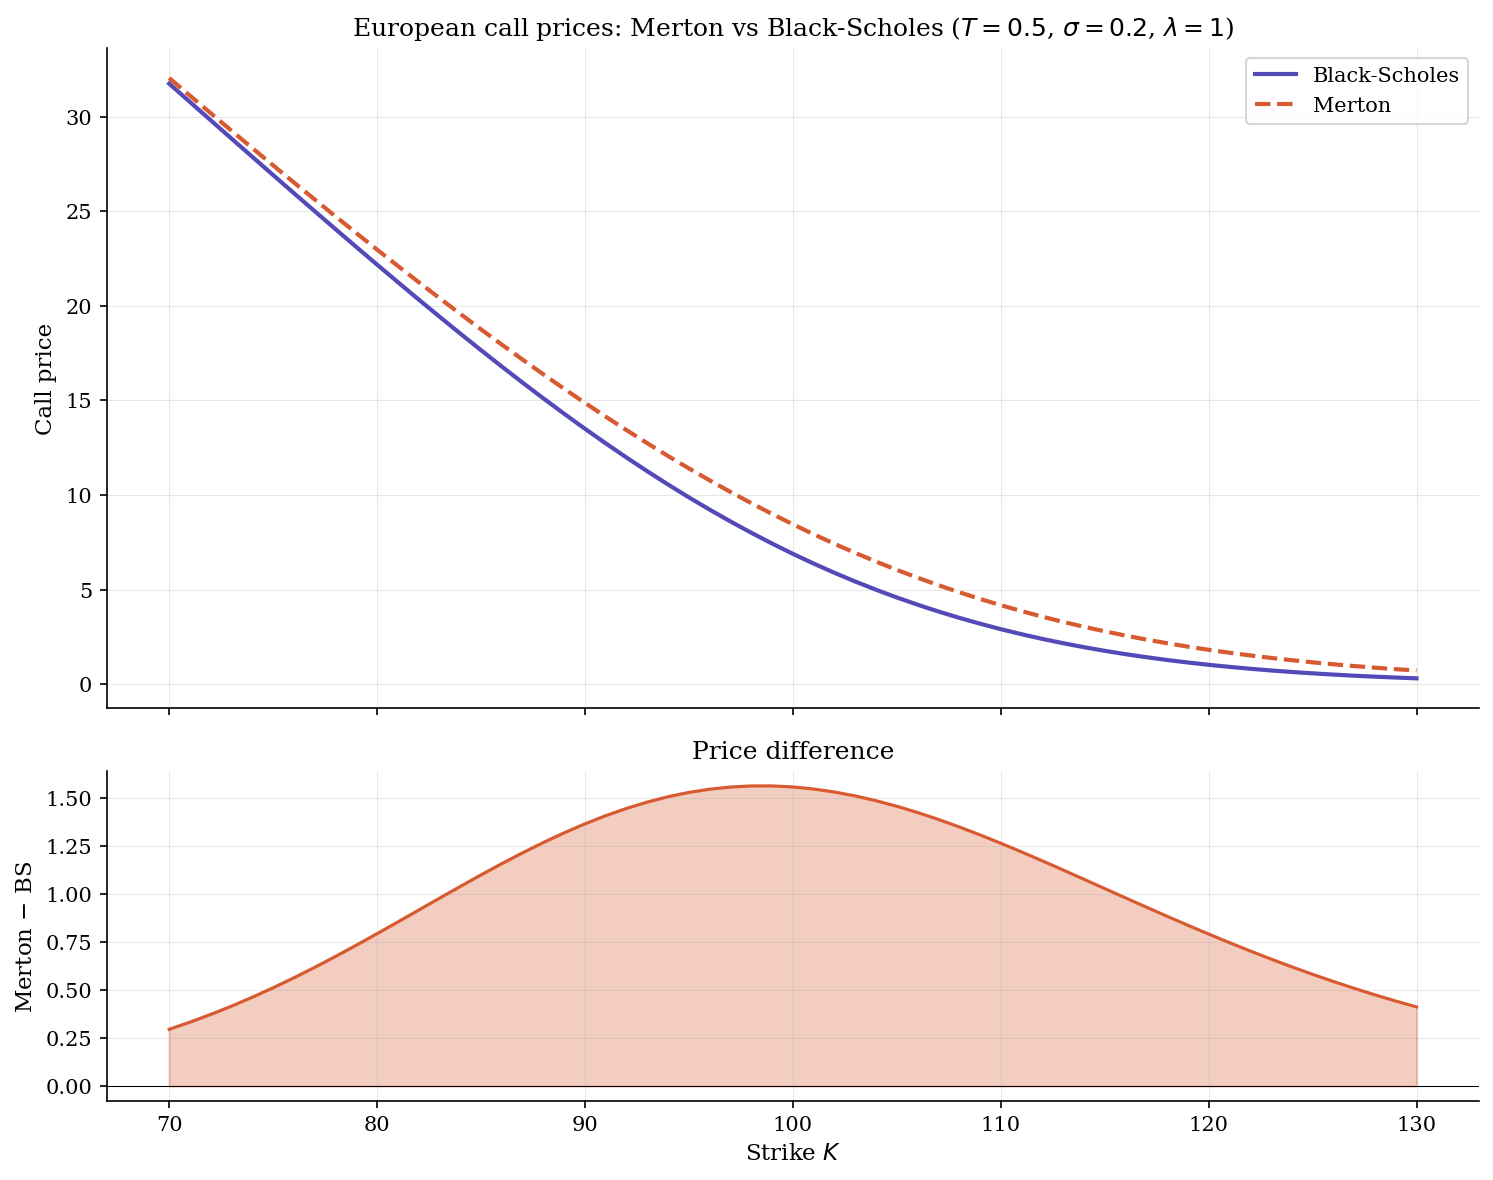

In [6]:
S_opt, T_opt, r_opt, sig_opt = 100.0, 0.5, 0.05, 0.2
lam_opt, muJ_opt, sigJ_opt = 1.0, -0.1, 0.15
K_range = np.arange(70, 131, 1.0)

bs_prices = np.array([bs_call(S_opt, K, T_opt, r_opt, sig_opt) for K in K_range])
merton_prices = np.array([
    merton_call(S_opt, K, T_opt, r_opt, sig_opt, lam_opt, muJ_opt, sigJ_opt)
    for K in K_range
])

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]},
)

ax1.plot(K_range, bs_prices, lw=2, color=COLORS[0], label='Black-Scholes')
ax1.plot(K_range, merton_prices, lw=2, ls='--', color=COLORS[2], label='Merton')
ax1.set_ylabel('Call price')
ax1.set_title(
    r'European call prices: Merton vs Black-Scholes'
    r' ($T=0.5$, $\sigma=0.2$, $\lambda=1$)'
)
ax1.legend()

diff = merton_prices - bs_prices
ax2.fill_between(K_range, diff, alpha=0.3, color=COLORS[2])
ax2.plot(K_range, diff, lw=1.5, color=COLORS[2])
ax2.axhline(0, color='black', lw=0.5)
ax2.set_xlabel(r'Strike $K$')
ax2.set_ylabel(r'Merton $-$ BS')
ax2.set_title('Price difference')

fig.tight_layout()
save_fig(fig, '02_options', 'merton_vs_bs_prices')
plt.show()

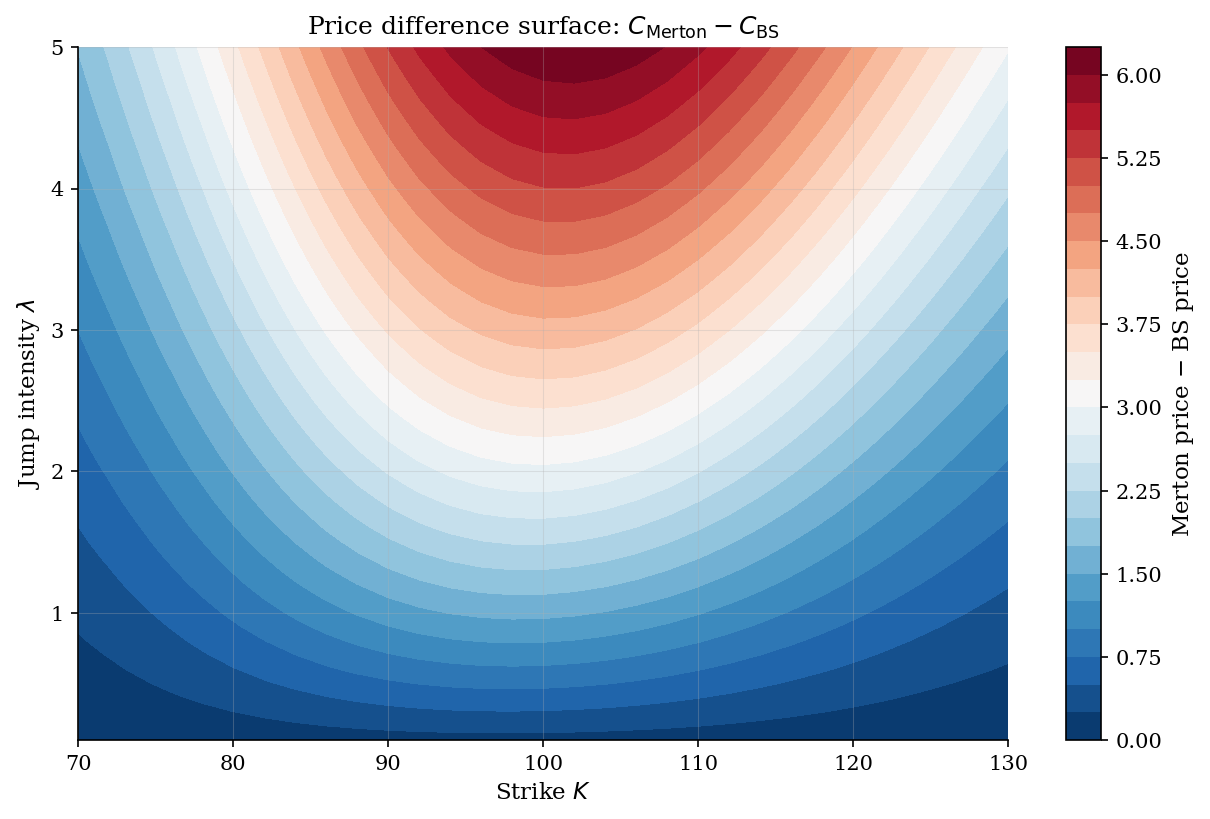

In [7]:
K_hm = np.arange(70, 131, 2.0)
lam_hm = np.linspace(0.1, 5.0, 50)
diff_grid = np.zeros((len(lam_hm), len(K_hm)))

for i, lam_i in enumerate(lam_hm):
    for j, K_j in enumerate(K_hm):
        diff_grid[i, j] = (
            merton_call(S_opt, K_j, T_opt, r_opt, sig_opt,
                        lam_i, muJ_opt, sigJ_opt)
            - bs_call(S_opt, K_j, T_opt, r_opt, sig_opt)
        )

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(K_hm, lam_hm, diff_grid, levels=30, cmap='RdBu_r')
fig.colorbar(cf, ax=ax, label=r'Merton price $-$ BS price')
ax.set_xlabel(r'Strike $K$')
ax.set_ylabel(r'Jump intensity $\lambda$')
ax.set_title(r'Price difference surface: $C_{\mathrm{Merton}} - C_{\mathrm{BS}}$')

save_fig(fig, '02_options', 'merton_price_diff_heatmap')
plt.show()

## Prosperity 4 Takeaways

- **Sudden dislocations.** Jump models capture the large instantaneous price moves
  common in Prosperity when aggressive orders sweep the book. Pure GBM underestimates
  the probability of these events.

- **Option pricing with jumps.** The Merton smile naturally produces higher OTM put
  prices (and OTM call prices) relative to Black-Scholes. If Prosperity introduces
  options or vouchers, pricing with a jump model avoids systematic under-hedging.

- **Fat-tail detection.** Compute the excess kurtosis of observed log-returns. Values
  significantly above zero indicate jump-like behaviour; fit $\lambda$, $\mu_J$,
  $\sigma_J$ via maximum likelihood or method of moments on the return sample.

- **Estimating $\lambda$ from data.** Count the fraction of time steps where
  $|r_t| > 3\hat{\sigma}$. This gives a rough estimate of the jump arrival rate
  $\hat{\lambda} \approx (\text{large-move count}) / (N \cdot \Delta t)$.

- **Spread adjustment.** When estimated jump risk $\lambda$ is high, widen
  market-making spreads to compensate for the increased adverse-selection risk:
  a sudden jump while holding inventory can cause outsized losses.